In [ ]:
import pandas as pd

filename = 'flight.csv'

try:
    df = pd.read_csv(filename)
    print(f"--- Successfully Loaded {filename} ---")
    print("\nCOLUMNS IN THIS DATASET:")
    print(list(df.columns))
    print("\nFIRST 5 ROWS:")
    print(df.head())
except Exception as e:
    print(f"Error loading file: {e}")

--- Successfully Loaded flight.csv ---

COLUMNS IN THIS DATASET:
['MEMBER_NO', 'FFP_DATE', 'FIRST_FLIGHT_DATE', 'GENDER', 'FFP_TIER', 'WORK_CITY', 'WORK_PROVINCE', 'WORK_COUNTRY', 'AGE', 'LOAD_TIME', 'FLIGHT_COUNT', 'BP_SUM', 'SUM_YR_1', 'SUM_YR_2', 'SEG_KM_SUM', 'LAST_FLIGHT_DATE', 'LAST_TO_END', 'AVG_INTERVAL', 'MAX_INTERVAL', 'EXCHANGE_COUNT', 'avg_discount', 'Points_Sum', 'Point_NotFlight']

FIRST 5 ROWS:
   MEMBER_NO   FFP_DATE FIRST_FLIGHT_DATE GENDER  FFP_TIER    WORK_CITY  \
0      54993  11/2/2006        12/24/2008   Male         6            .   
1      28065  2/19/2007          8/3/2007   Male         6          NaN   
2      55106   2/1/2007         8/30/2007   Male         6            .   
3      21189  8/22/2008         8/23/2008   Male         5  Los Angeles   
4      39546  4/10/2009         4/15/2009   Male         6      guiyang   

  WORK_PROVINCE WORK_COUNTRY   AGE  LOAD_TIME  ...  SUM_YR_2  SEG_KM_SUM  \
0       beijing           CN  31.0  3/31/2014  ...  234188.0

In [ ]:
import os
print(os.path.abspath("voyage_ai_data.csv"))

/content/voyage_ai_data.csv


--- Data Loaded Successfully ---
Total Records: 62988
Records after cleaning: 60548

Calculating Optimal Clusters...


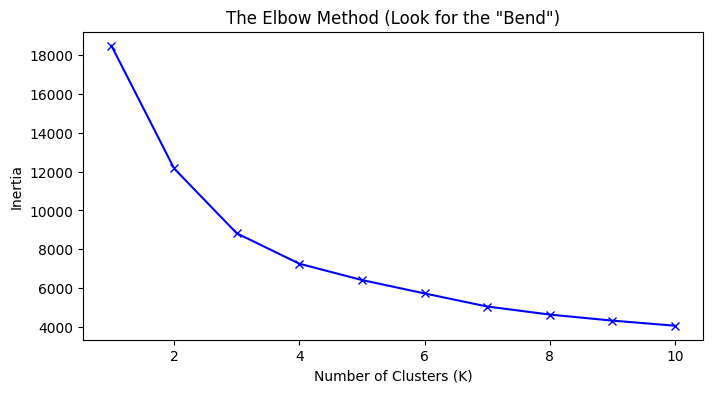

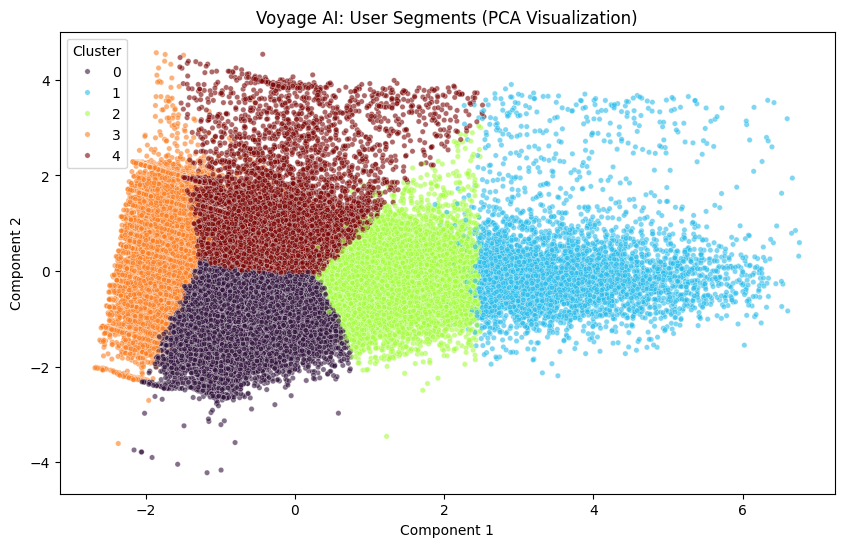


--- CLUSTER PROFILES (Average Values) ---
         FLIGHT_COUNT    SEG_KM_SUM  LAST_TO_END  avg_discount
Cluster                                                       
0            5.841132   8646.867793   123.699654      0.577617
1           39.035707  53556.975694    31.855453      0.771493
2           18.262865  26542.530900    61.883242      0.712906
3            3.858613   6002.768399   482.742460      0.703467
4            6.591664   8605.379991   134.871976      0.878989

Analysis Complete! Downloading 'voyage_ai_final_results.csv' to your computer...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from google.colab import files

# ==========================================
# 1. LOAD DATA
# ==========================================
filename = 'flight.csv'

try:
    df = pd.read_csv(filename)
    print("--- Data Loaded Successfully ---")
    print(f"Total Records: {len(df)}")
except FileNotFoundError:
    print("Error: File not found. Please check the filename path.")
    exit()

# ==========================================
# 2. DATA CLEANING & SELECTION
# ==========================================
# We select only the columns relevant to behavior
selected_features = ['FLIGHT_COUNT', 'SEG_KM_SUM', 'LAST_TO_END', 'avg_discount']

# Create a new clean dataframe
df_clean = df[selected_features].copy()

# Drop missing values (Machine learning cannot handle blank cells)
df_clean = df_clean.dropna()
# --- OUTLIER REMOVAL ---
# Remove the top 1% of extreme values to prevent them from skewing the model
for col in selected_features:
    upper_limit = df_clean[col].quantile(0.99)
    df_clean = df_clean[df_clean[col] <= upper_limit]


print(f"Records after cleaning: {len(df_clean)}")

# ==========================================
# 3. SCALING (CRITICAL STEP)
# ==========================================
# We must scale because 'SEG_KM_SUM' is huge (300,000) and 'avg_discount' is tiny (1.0).
# Without scaling, the distance would dominate the model.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clean)

# ==========================================
# 4. ELBOW METHOD (To find optimal K)
# ==========================================
print("\nCalculating Optimal Clusters...")
inertia = []
range_values = range(1, 11)

# We use a sample of 5000 rows to make the graph render faster
sample_X = X_scaled[:5000]

for i in range_values:
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(sample_X)
    inertia.append(kmeans.inertia_)

# Plot the Elbow Graph
plt.figure(figsize=(8, 4))
plt.plot(range_values, inertia, 'bx-')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.title('The Elbow Method (Look for the "Bend")')
plt.show()

# ==========================================
# 5. APPLY CLUSTERING
# ==========================================
# We will use K=5
k = 5
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

# Add the Cluster labels back to our dataframe
df_clean['Cluster'] = clusters

# ==========================================
# 6. VISUALIZATION (PCA)
# ==========================================
# Squeeze 4 dimensions down to 2 dimensions so we can draw a 2D graph
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

plt.figure(figsize=(10, 6))
sns.scatterplot(
    x=principal_components[:, 0],
    y=principal_components[:, 1],
    hue=df_clean['Cluster'],
    palette='turbo',
    alpha=0.6,
    s=15
)
plt.title('Voyage AI: User Segments (PCA Visualization)')
plt.xlabel('Component 1')
plt.ylabel('Component 2')
plt.legend(title='Cluster')
plt.show()

# ==========================================
# 7. BUSINESS INTERPRETATION (THE "SO WHAT?")
# ==========================================
print("\n--- CLUSTER PROFILES (Average Values) ---")
# Group by cluster to see the average behavior of each group
summary = df_clean.groupby('Cluster').mean()
print(summary)

# ==========================================
# 8. DOWNLOAD RESULTS
# ==========================================
output_file = 'voyage_ai_final_results.csv'
df_clean.to_csv(output_file, index=False)
print(f"\nAnalysis Complete! Downloading '{output_file}' to your computer...")
files.download(output_file)